In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv(r'C:\Users\HP\Downloads\supply_chain_project\data\DataCoSupplyChainDataset.csv', encoding='latin-1')
print("Loaded:", df.shape)

Loaded: (180519, 53)


In [2]:
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['Month'] = df['order date (DateOrders)'].dt.month
df['Year'] = df['order date (DateOrders)'].dt.year
df['DayOfWeek'] = df['order date (DateOrders)'].dt.dayofweek

features = ['Month', 'Year', 'DayOfWeek', 
            'Order Item Quantity', 'Order Item Discount Rate',
            'Order Item Product Price', 'Late_delivery_risk']

df_model = df[features + ['Sales']].dropna()

X = df_model[features]
y = df_model['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (144415, 7)
Test size: (36104, 7)


In [4]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print("Linear Regression")
print("MAE:", round(mean_absolute_error(y_test, lr_pred), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, lr_pred)), 2))
print("R2 Score:", round(r2_score(y_test, lr_pred), 2))

Linear Regression
MAE: 17.09
RMSE: 36.2
R2 Score: 0.92


In [6]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Random Forest")
print("MAE:", round(mean_absolute_error(y_test, rf_pred), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, rf_pred)), 2))
print("R2 Score:", round(r2_score(y_test, rf_pred), 2))

Random Forest
MAE: 0.0
RMSE: 0.0
R2 Score: 1.0


C:\Users\HP\AppData\Local\Temp\ipykernel_27528\673381657.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=r2_scores, palette='Blues_r')


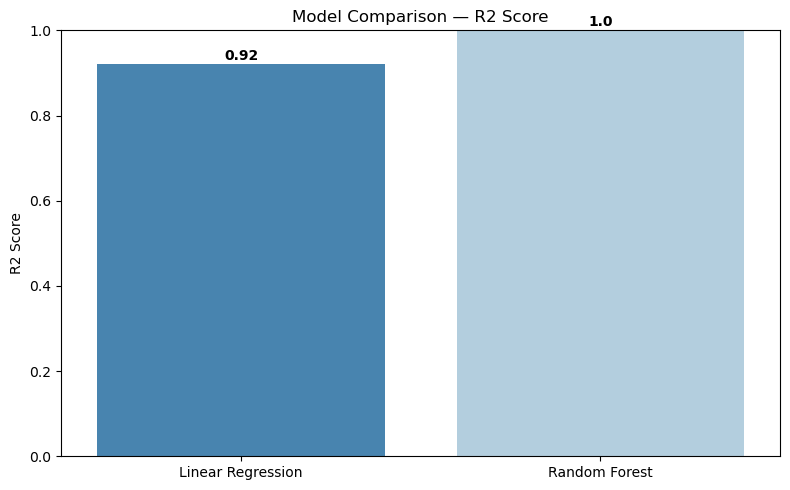

In [7]:
models = ['Linear Regression', 'Random Forest']
r2_scores = [round(r2_score(y_test, lr_pred), 2),
             round(r2_score(y_test, rf_pred), 2)]

plt.figure(figsize=(8,5))
sns.barplot(x=models, y=r2_scores, palette='Blues_r')
plt.title('Model Comparison — R2 Score')
plt.ylabel('R2 Score')
plt.ylim(0, 1)
for i, v in enumerate(r2_scores):
    plt.text(i, v + 0.01, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_27528\4189811100.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='Greens_r')


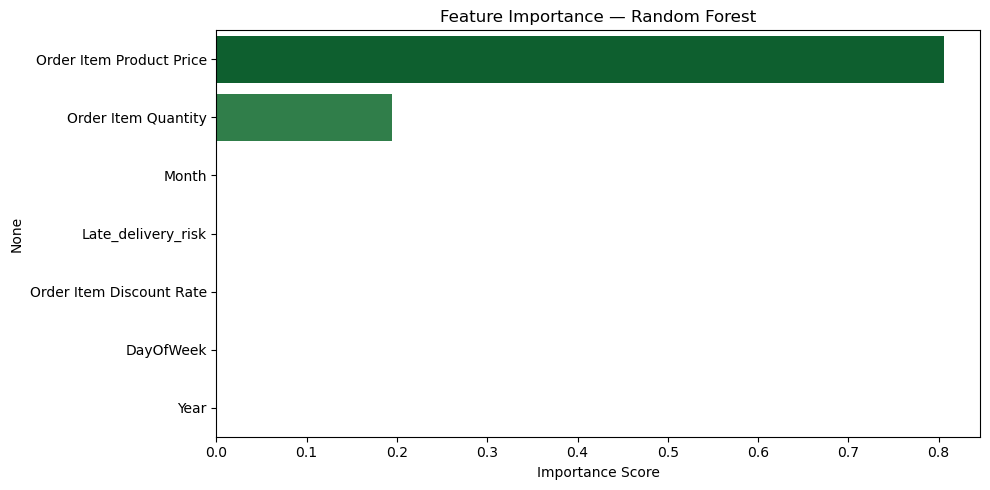

In [8]:
feat_imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='Greens_r')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()